In [1]:
# Cell 1 — Imports and load all data needed for leakage analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv

load_dotenv()

password = quote_plus(os.getenv('DB_PASSWORD'))
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}",
    pool_pre_ping=True
)

# load all tables including RFM we saved yesterday
orders      = pd.read_sql("SELECT * FROM orders", engine)
payments    = pd.read_sql("SELECT * FROM order_payments", engine)
rfm         = pd.read_sql("SELECT * FROM rfm_segments", engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)
customers   = pd.read_sql("SELECT * FROM customers", engine)

# convert dates
orders['order_purchase_timestamp']        = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date']   = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']   = pd.to_datetime(orders['order_estimated_delivery_date'])

print(" All data loaded!")
print(f"Orders:    {len(orders):,}")
print(f"Payments:  {len(payments):,}")
print(f"RFM:       {len(rfm):,} customers with segments")
print(f"Segments:  {rfm['segment'].unique()}")

 All data loaded!
Orders:    99,441
Payments:  103,886
RFM:       96,478 customers with segments
Segments:  <ArrowStringArray>
[            'At Risk',      'Lost Customers',  'High Value Churned',
     'Loyal Customers', 'Recent Low Spenders',           'Champions']
Length: 6, dtype: str


In [3]:
# Cell 2 — Leakage Source 1: Cancelled and Unavailable Orders

# Step 1 — get incomplete orders
cancelled   = orders[orders['order_status'] == 'canceled']
unavailable = orders[orders['order_status'] == 'unavailable']
incomplete  = orders[orders['order_status'].isin(['canceled','unavailable'])]

# Step 2 — calculate revenue lost
cancelled_rev   = cancelled.merge(payments, on='order_id', how='left')['payment_value'].sum()
unavailable_rev = unavailable.merge(payments, on='order_id', how='left')['payment_value'].sum()
total_incomplete_rev = incomplete.merge(payments, on='order_id', how='left')['payment_value'].sum()

# Step 3 — total platform revenue for context
total_revenue = payments['payment_value'].sum()

print("="*55)
print(" LEAKAGE SOURCE 1 — INCOMPLETE ORDERS")
print("="*55)
print(f"Cancelled orders:       {len(cancelled):,}  — R$ {cancelled_rev:,.2f}")
print(f"Unavailable orders:     {len(unavailable):,}  — R$ {unavailable_rev:,.2f}")
print(f"Total incomplete:       {len(incomplete):,}  — R$ {total_incomplete_rev:,.2f}")
print(f"% of total revenue:     {total_incomplete_rev/total_revenue*100:.2f}%")

# Step 4 — store for final summary
leakage_1 = total_incomplete_rev
print(f"\nLeakage 1 recorded: R$ {leakage_1:,.2f}")

 LEAKAGE SOURCE 1 — INCOMPLETE ORDERS
Cancelled orders:       625  — R$ 143,255.60
Unavailable orders:     609  — R$ 126,479.51
Total incomplete:       1,234  — R$ 269,735.11
% of total revenue:     1.68%

Leakage 1 recorded: R$ 269,735.11


In [4]:
# Cell 3 — Leakage Source 2: High Value Churned Customers

# Step 1 — get High Value Churned segment
churned = rfm[rfm['segment'] == 'High Value Churned']

# Step 2 — calculate their revenue
churned_revenue = churned['monetary'].sum()
churned_avg     = churned['monetary'].mean()
churned_count   = len(churned)

# Step 3 — what if we recovered even 10% of them?
recovery_10pct  = churned_revenue * 0.10
recovery_20pct  = churned_revenue * 0.20

# Step 4 — At Risk customers (about to churn)
at_risk         = rfm[rfm['segment'] == 'At Risk']
at_risk_revenue = at_risk['monetary'].sum()

print("="*55)
print(" LEAKAGE SOURCE 2 — CHURNED CUSTOMERS")
print("="*55)
print(f"High Value Churned customers:  {churned_count:,}")
print(f"Revenue already lost:          R$ {churned_revenue:,.2f}")
print(f"Average spend per customer:    R$ {churned_avg:,.2f}")
print(f"Days since last purchase (avg): {churned['recency'].mean():.0f} days")
print(f"\n  AT RISK customers:          {len(at_risk):,}")
print(f"Revenue at risk:               R$ {at_risk_revenue:,.2f}")
print(f"Average spend per customer:    R$ {at_risk['monetary'].mean():,.2f}")

print(f"\n RECOVERY POTENTIAL:")
print(f"If 10% of churned return:  R$ {recovery_10pct:,.2f} recovered")
print(f"If 20% of churned return:  R$ {recovery_20pct:,.2f} recovered")

# store for final summary
leakage_2 = churned_revenue
leakage_2_at_risk = at_risk_revenue
print(f"\n Leakage 2 recorded: R$ {leakage_2:,.2f}")

 LEAKAGE SOURCE 2 — CHURNED CUSTOMERS
High Value Churned customers:  15,056
Revenue already lost:          R$ 4,514,570.59
Average spend per customer:    R$ 299.85
Days since last purchase (avg): 446 days

  AT RISK customers:          15,312
Revenue at risk:               R$ 1,216,064.59
Average spend per customer:    R$ 79.42

 RECOVERY POTENTIAL:
If 10% of churned return:  R$ 451,457.06 recovered
If 20% of churned return:  R$ 902,914.12 recovered

 Leakage 2 recorded: R$ 4,514,570.59


In [6]:
# Cell 4 — Leakage Source 3: Late Delivery Impact on Revenue

# Step 1 — calculate delivery delays
delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_purchase_timestamp']
).dt.days
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_estimated_delivery_date']
).dt.days

# Step 2 — remove Sept 19 2017 anomaly (found in EDA)
delivered = delivered[
    ~delivered['order_delivered_customer_date'].dt.date.astype(str).str.startswith('2017-09-19')
]

# Step 3 — late orders
late_orders = delivered[delivered['delay_days'] > 0]
late_revenue = late_orders.merge(payments, on='order_id', how='left')
late_revenue_total = late_revenue['payment_value'].sum()

# Step 4 — load reviews to check late delivery vs bad reviews
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
late_with_reviews = late_orders.merge(reviews, on='order_id', how='left')
on_time_with_reviews = delivered[delivered['delay_days'] <= 0].merge(reviews, on='order_id', how='left')

late_avg_rating   = late_with_reviews['review_score'].mean()
ontime_avg_rating = on_time_with_reviews['review_score'].mean()

# Step 5 — bad reviews from late orders
bad_reviews_late = late_with_reviews[late_with_reviews['review_score'] <= 2]

print("="*55)
print(" LEAKAGE SOURCE 3 — LATE DELIVERY IMPACT")
print("="*55)
print(f"Total late orders:           {len(late_orders):,}")
print(f"Late delivery rate:          {len(late_orders)/len(delivered)*100:.1f}%")
print(f"Revenue from late orders:    R$ {late_revenue_total:,.2f}")
print(f"\nAvg rating — ON TIME:        {ontime_avg_rating:.2f} ")
print(f"Avg rating — LATE:           {late_avg_rating:.2f} ")
print(f"Rating drop from delay:      {ontime_avg_rating - late_avg_rating:.2f} stars")
print(f"\nBad reviews (≤2★) from late: {len(bad_reviews_late):,}")
print(f"Bad review rate — late:      {len(bad_reviews_late)/len(late_with_reviews)*100:.1f}%")

# Step 6 — estimate indirect revenue loss from bad reviews
# assume each bad review loses 3 potential customers at avg R$159
lost_potential = len(bad_reviews_late) * 3 * 159.85
print(f"\n INDIRECT LOSS ESTIMATE:")
print(f"Each bad review deters ~3 new customers")
print(f"Avg order value: R$ 159.85")
print(f"Estimated indirect loss: R$ {lost_potential:,.2f}")

leakage_3 = late_revenue_total
print(f"\n Leakage 3 recorded: R$ {leakage_3:,.2f}")

 LEAKAGE SOURCE 3 — LATE DELIVERY IMPACT
Total late orders:           6,481
Late delivery rate:          6.7%
Revenue from late orders:    R$ 1,141,166.78

Avg rating — ON TIME:        4.29 
Avg rating — LATE:           2.26 
Rating drop from delay:      2.03 stars

Bad reviews (≤2★) from late: 3,983
Bad review rate — late:      61.2%

 INDIRECT LOSS ESTIMATE:
Each bad review deters ~3 new customers
Avg order value: R$ 159.85
Estimated indirect loss: R$ 1,910,047.65

 Leakage 3 recorded: R$ 1,141,166.78


 TOTAL REVENUE LEAKAGE REPORT — OLIST E-COMMERCE

Total Platform Revenue:     R$ 16,008,872.12

REVENUE LEAKAGE BREAKDOWN:
------------------------------------------------------------
Cancelled & Unavailable Orders      R$   269,735.11  (1.7%)
High Value Churned Customers        R$ 4,514,570.59  (28.2%)
At Risk Customers                   R$ 1,216,064.59  (7.6%)
Late Delivery Revenue               R$ 1,141,166.78  (7.1%)
------------------------------------------------------------
TOTAL LEAKAGE                       R$ 7,141,537.07  (44.6%)


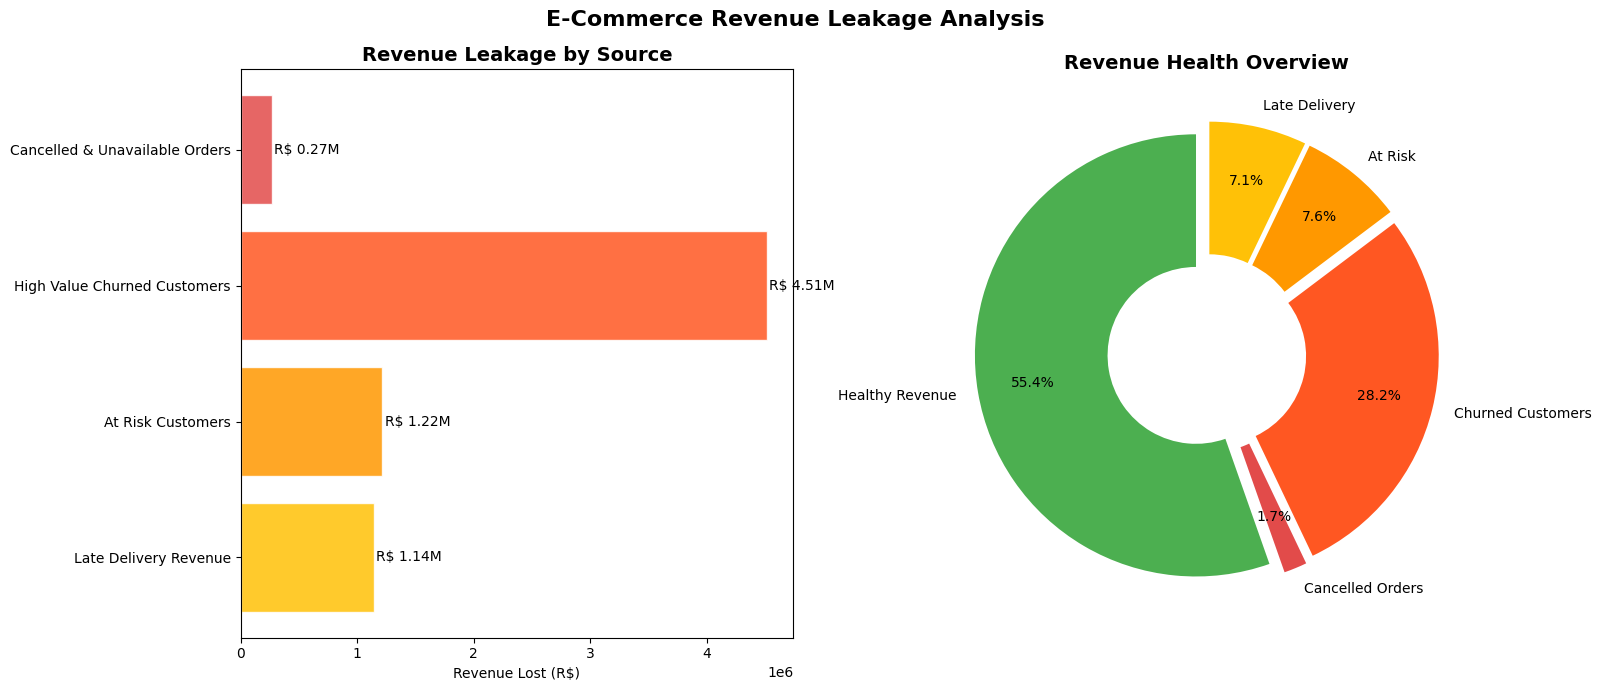


 TOP 3 BUSINESS RECOMMENDATIONS

1. WIN-BACK CAMPAIGN — High Value Churned
   Target: 15,056 customers (avg R$300 spend)
   Action: personalised email + 15% discount
   Potential recovery (10%): R$ 451,457

2. FIX DELIVERY IN PROBLEM CITIES
   6,481 late orders — 61% get bad reviews
   Action: partner with faster logistics in 
   top delay cities
   Rating improvement: 2.26 → 4.29 

3. RETAIN AT RISK CUSTOMERS NOW
   15,312 customers — R$ 1,216,065 at stake
   Action: loyalty rewards before they churn
   Prevent loss of R$ 1,216,065



In [7]:
# Cell 5 — FINAL REVENUE LEAKAGE SUMMARY

total_revenue = payments['payment_value'].sum()

# all leakage sources
leakage_sources = {
    'Cancelled & Unavailable Orders': leakage_1,
    'High Value Churned Customers':   leakage_2,
    'At Risk Customers':              leakage_2_at_risk,
    'Late Delivery Revenue':          leakage_3,
}

total_leakage = sum(leakage_sources.values())

print("="*60)
print(" TOTAL REVENUE LEAKAGE REPORT — OLIST E-COMMERCE")
print("="*60)
print(f"\nTotal Platform Revenue:     R$ {total_revenue:,.2f}")
print(f"\nREVENUE LEAKAGE BREAKDOWN:")
print("-"*60)
for source, amount in leakage_sources.items():
    pct = amount/total_revenue*100
    print(f"{source:<35} R$ {amount:>12,.2f}  ({pct:.1f}%)")
print("-"*60)
print(f"{'TOTAL LEAKAGE':<35} R$ {total_leakage:>12,.2f}  ({total_leakage/total_revenue*100:.1f}%)")

# Step 2 — waterfall chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# chart 1 — leakage breakdown bar
sources = list(leakage_sources.keys())
amounts = list(leakage_sources.values())
bar_colors = ['#E24B4A','#FF5722','#FF9800','#FFC107']

bars = axes[0].barh(sources, amounts, color=bar_colors, 
                    alpha=0.85, edgecolor='white')
axes[0].set_title('Revenue Leakage by Source', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenue Lost (R$)')
for bar, val in zip(bars, amounts):
    axes[0].text(val + 20000, bar.get_y() + bar.get_height()/2,
                 f'R$ {val/1000000:.2f}M', va='center', fontsize=10)
axes[0].invert_yaxis()

# chart 2 — healthy vs leaked revenue
labels = ['Healthy Revenue', 'Cancelled Orders', 
          'Churned Customers', 'At Risk', 'Late Delivery']
values = [
    total_revenue - total_leakage,
    leakage_1, leakage_2, 
    leakage_2_at_risk, leakage_3
]
colors_pie = ['#4CAF50','#E24B4A','#FF5722','#FF9800','#FFC107']
explode = (0.05, 0.05, 0.05, 0.05, 0.05)

axes[1].pie(values, labels=labels, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            explode=explode, pctdistance=0.75,
            wedgeprops=dict(width=0.6))
axes[1].set_title('Revenue Health Overview', 
                  fontsize=14, fontweight='bold')

plt.suptitle('E-Commerce Revenue Leakage Analysis', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/revenue_leakage_summary.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Step 3 — recommendations
print("\n" + "="*60)
print(" TOP 3 BUSINESS RECOMMENDATIONS")
print("="*60)
print(f"""
1. WIN-BACK CAMPAIGN — High Value Churned
   Target: 15,056 customers (avg R$300 spend)
   Action: personalised email + 15% discount
   Potential recovery (10%): R$ {leakage_2*0.10:,.0f}

2. FIX DELIVERY IN PROBLEM CITIES
   6,481 late orders — 61% get bad reviews
   Action: partner with faster logistics in 
   top delay cities
   Rating improvement: 2.26 → 4.29 

3. RETAIN AT RISK CUSTOMERS NOW
   15,312 customers — R$ {leakage_2_at_risk:,.0f} at stake
   Action: loyalty rewards before they churn
   Prevent loss of R$ {leakage_2_at_risk:,.0f}
""")